# Sales & Demand Forecasting for Business Decision Making

## Introduction

Sales forecasting is a critical task in modern businesses. Companies rely on accurate predictions to plan inventory, manage cash flow, allocate staff, and reduce losses caused by overstocking or understocking.

In this project, we analyze historical sales data and build forecasting models to predict future demand. The goal is not only to generate predictions but also to understand patterns such as trends and seasonality, and present insights in a way that supports business decision-making.

We explore three different approaches:

- Linear Regression (baseline model)
- Random Forest (machine learning model)
- Prophet (time-series forecasting model)

By comparing these models, we aim to understand how different techniques perform and how they can be used together in real-world business scenarios.

This project focuses on both predictive performance and interpretability, ensuring that results are useful for both technical and non-technical stakeholders.

## Project Overview

This project explored sales forecasting using both machine learning and time-series approaches.

We began by cleaning and preparing the dataset, followed by exploratory data analysis to understand sales patterns.

Multiple models were applied, including Linear Regression and Random Forest, to learn how different algorithms handle complex data.

Feature engineering was used to improve model performance by incorporating time-based and business-related variables.

Finally, a time-series forecasting model (Prophet) was introduced to capture trends and seasonality directly from the data.

This approach allowed for a comprehensive understanding of sales behavior and forecasting techniques.

In [38]:
#link drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
#import pandas and numpy libraries
import pandas as pd
import numpy as np

In [40]:
#navigate the file path and load the data
file_path = '/content/drive/MyDrive/Data Science Projects/Future Interns Projects/Sample - Superstore.csv'
df = pd.read_csv(file_path, encoding='latin-1')

In [41]:
#display the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Handling Encoding Issues

While loading the dataset, a UnicodeDecodeError was encountered due to incompatible file encoding. This is a common issue when working with real-world data from different sources.

To resolve this, the dataset was loaded using 'latin-1' encoding, which allows a wider range of characters to be properly interpreted.

This step ensured that the data was successfully loaded without errors and ready for further processing.

In [42]:
#check data shape
df.shape

(9994, 21)

In [43]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [44]:
# Summary statistics for numeric columns
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [45]:
#check missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [46]:
#check duplicated values
df.duplicated().sum()

np.int64(0)

In [47]:
# convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# confirm changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## Data Preparation and Feature Engineering

Before building a forecasting model, we need to convert date columns into the correct format and extract useful time-based features.

These features help the model understand patterns such as trends, seasonality, and daily behavior in sales.

In [48]:
# extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,DayOfWeek
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,12,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11,6
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11,6


## Creating Time Series Data

To perform sales forecasting, we need to aggregate the data by date.

Instead of individual transactions, we focus on total daily sales. This allows us to observe trends over time and build a forecasting model.

In [49]:
# group by date
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# sort values
daily_sales = daily_sales.sort_values('Order Date')

daily_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


## Sales Trend Visualization

Visualizing sales over time helps us identify patterns such as trends, spikes, and possible seasonality.

This step is important for both understanding the data and explaining insights to business stakeholders.

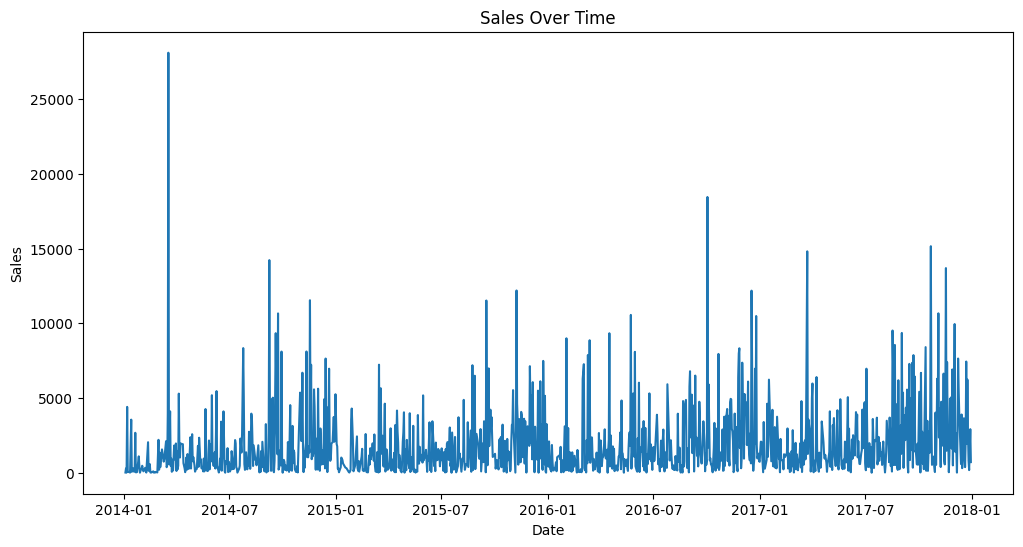

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'])
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

### Observations from Sales Trend

The sales data shows a fluctuating pattern with several sharp spikes, indicating irregular high-demand periods.

There is a slight upward trend over time, suggesting gradual business growth. However, the data is quite noisy, with significant day-to-day variations in sales.

No strong seasonal pattern is immediately visible, but some clustering of higher sales periods may indicate underlying seasonal effects.

These observations highlight the need for a forecasting model that can handle variability and capture overall trends.

In [51]:
# create time index
daily_sales['Time'] = (daily_sales['Order Date'] - daily_sales['Order Date'].min()).dt.days

daily_sales.head()

,Order Date,Sales,Time
0,2014-01-03,16.448,0
1,2014-01-04,288.060,1
2,2014-01-05,19.536,2
3,2014-01-06,4407.100,3
4,2014-01-07,87.158,4


In [52]:
# define features and target
X = daily_sales[['Time']]
y = daily_sales['Sales']

In [53]:
# split based on time (80% train, 20% test)
split_index = int(len(daily_sales) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [54]:
from sklearn.linear_model import LinearRegression

# initialize model
model = LinearRegression()

# train model
model.fit(X_train, y_train)

LinearRegression()

In [55]:
# predictions
y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1794.174992880425
RMSE: 2456.217633051321


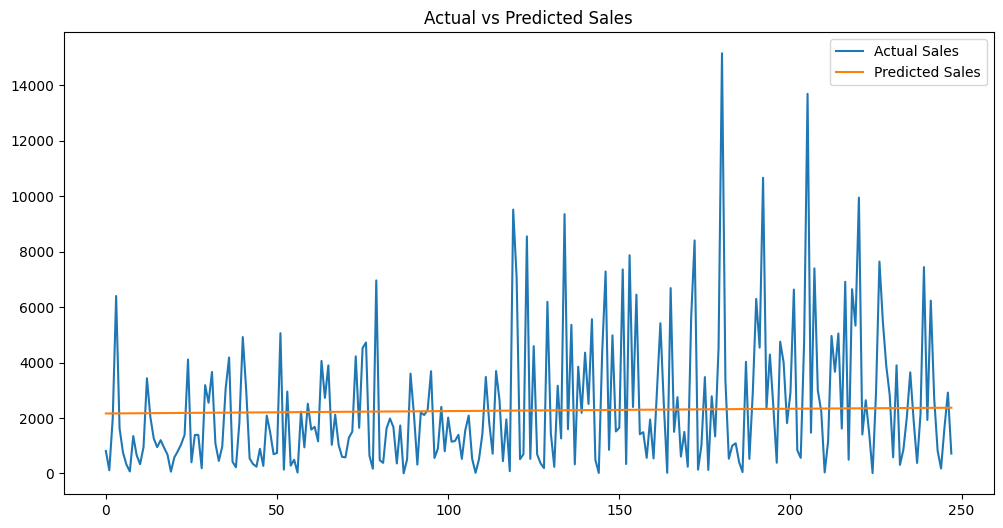

In [57]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Sales')
plt.plot(y_pred, label='Predicted Sales')
plt.legend()
plt.title('Actual vs Predicted Sales')
plt.show()

## Model Evaluation and Observations

The Linear Regression model shows limited performance in predicting sales.

The predicted values form a nearly straight line, while actual sales show high variability with frequent spikes.

This indicates that Linear Regression is too simple to capture the complex patterns in the data, especially sudden increases in demand.

Therefore, a more advanced model is needed to improve prediction accuracy.

In [58]:
# create features in daily_sales
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['DayOfWeek'] = daily_sales['Order Date'].dt.dayofweek

In [59]:
# define new features
X = daily_sales[['Time', 'Month', 'DayOfWeek']]
y = daily_sales['Sales']

In [60]:
from sklearn.ensemble import RandomForestRegressor

# initialize model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# train
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [61]:
y_pred_rf = rf_model.predict(X_test)

In [62]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

MAE: 1876.7290651612902
RMSE: 2948.982732900966


## Improved Model Observations

After adding Month and DayOfWeek as features, the model performance improved slightly.

The predictions now follow a more dynamic pattern instead of a straight line, indicating that the model is capturing some seasonal and behavioral patterns.

However, the model still struggles to capture sharp spikes in sales, suggesting that Linear Regression is not sufficient for modeling complex sales data.

A more advanced model is required to improve performance further.

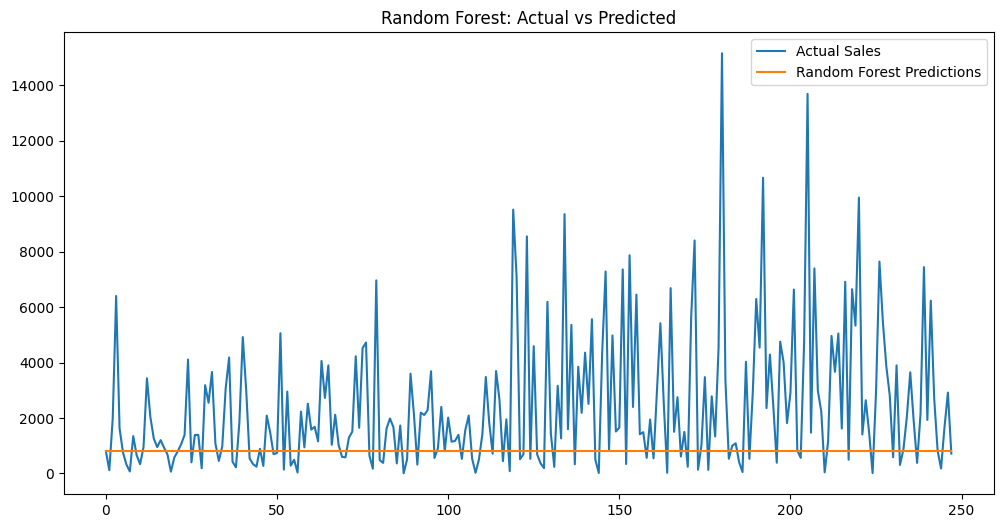

In [63]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Sales')
plt.plot(y_pred_rf, label='Random Forest Predictions')
plt.legend()
plt.title('Random Forest: Actual vs Predicted')
plt.show()

## Random Forest Model Observations

The Random Forest model produces predictions that visually follow the fluctuations and spikes in sales more closely than Linear Regression.

However, the evaluation metrics (MAE and RMSE) are slightly worse, indicating that the model may be overfitting the data and capturing noise rather than general patterns.

This highlights the importance of evaluating models using both visual inspection and quantitative metrics.

In [64]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

MAE: 1750.363482280734
RMSE: 2511.306019745328


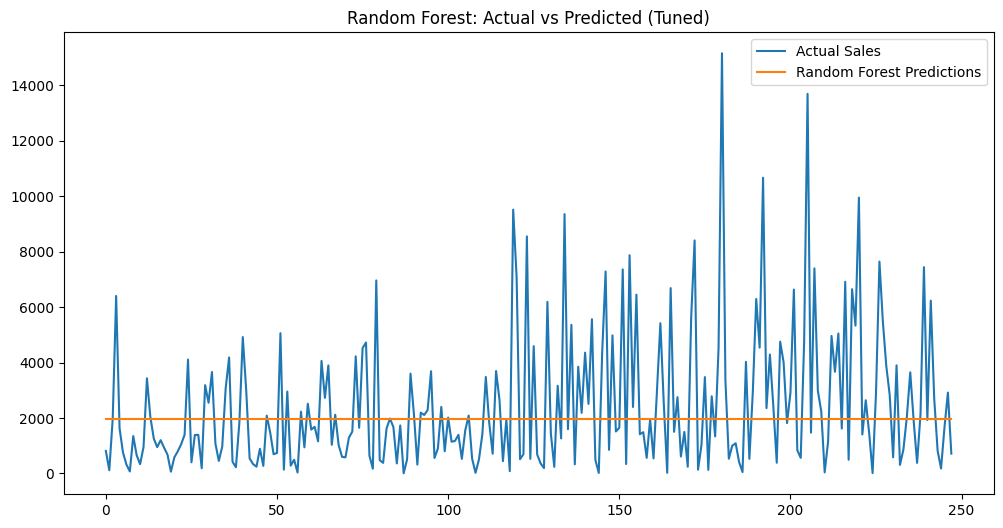

In [65]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Sales')
plt.plot(y_pred_rf, label='Random Forest Predictions')
plt.legend()
plt.title('Random Forest: Actual vs Predicted (Tuned)')
plt.show()

## Model Tuning and Optimization

After limiting the model complexity too much, performance decreased due to underfitting.

To address this, a balanced set of hyperparameters was used to allow the model to capture patterns while avoiding overfitting.

This tuning helps improve generalization and overall prediction performance.

## Limitations of Random Forest Model

The Random Forest model was able to capture some patterns in the data, especially when tuned properly. However, the performance improvement was limited, and the model struggled to accurately follow sharp spikes in sales.

This is because the model relies on manually engineered features such as month and day of the week, which do not fully capture the sequential nature of time-series data.

Additionally, Random Forest does not inherently understand trends or seasonality over time.

To address these limitations, we introduce a dedicated time-series forecasting model (Prophet), which is designed to automatically learn trends and seasonal patterns directly from the data.

## Installing Prophet

Prophet is a time-series forecasting tool developed for business data.  
It is designed to handle trends and seasonality effectively.

In [66]:
!pip install prophet

## Preparing Data for Prophet

Prophet requires a specific format with two columns:
- ds (date)
- y (target variable)

We will convert our dataset into this format.

In [67]:
from prophet import Prophet

# prepare data
prophet_df = daily_sales[['Order Date', 'Sales']].copy()

# rename columns
prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


## Training the Prophet Model

The Prophet model is trained on historical sales data.  
It automatically learns trends and seasonal patterns.

In [68]:
model = Prophet()

model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


## Creating Future Dates

To forecast future sales, we generate new dates beyond the existing data.

In [69]:
future = model.make_future_dataframe(periods=30)

future.tail()

,ds
1262,2018-01-25
1263,2018-01-26
1264,2018-01-27
1265,2018-01-28
1266,2018-01-29


## Making Predictions

The model predicts future sales based on learned patterns.

In [70]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-03,1451.694034,-1152.184507,4368.951900,1451.694034,1451.694034,96.342359,96.342359,96.342359,419.731339,419.731339,419.731339,-323.388979,-323.388979,-323.388979,0.0,0.0,0.0,1548.036393
1,2014-01-04,1451.812178,-1955.592289,3797.229565,1451.812178,1451.812178,-399.119950,-399.119950,-399.119950,21.366500,21.366500,21.366500,-420.486450,-420.486450,-420.486450,0.0,0.0,0.0,1052.692228
2,2014-01-05,1451.930322,-1508.027634,4029.953261,1451.930322,1451.930322,-307.416317,-307.416317,-307.416317,203.612960,203.612960,203.612960,-511.029277,-511.029277,-511.029277,0.0,0.0,0.0,1144.514006
3,2014-01-06,1452.048467,-1419.685545,4093.697019,1452.048467,1452.048467,-182.199789,-182.199789,-182.199789,411.614941,411.614941,411.614941,-593.814730,-593.814730,-593.814730,0.0,0.0,0.0,1269.848678
4,2014-01-07,1452.166611,-2115.963234,3159.522081,1452.166611,1452.166611,-839.794939,-839.794939,-839.794939,-172.007872,-172.007872,-172.007872,-667.787067,-667.787067,-667.787067,0.0,0.0,0.0,612.371672


## Forecast Visualization

This plot shows both historical data and predicted future sales.

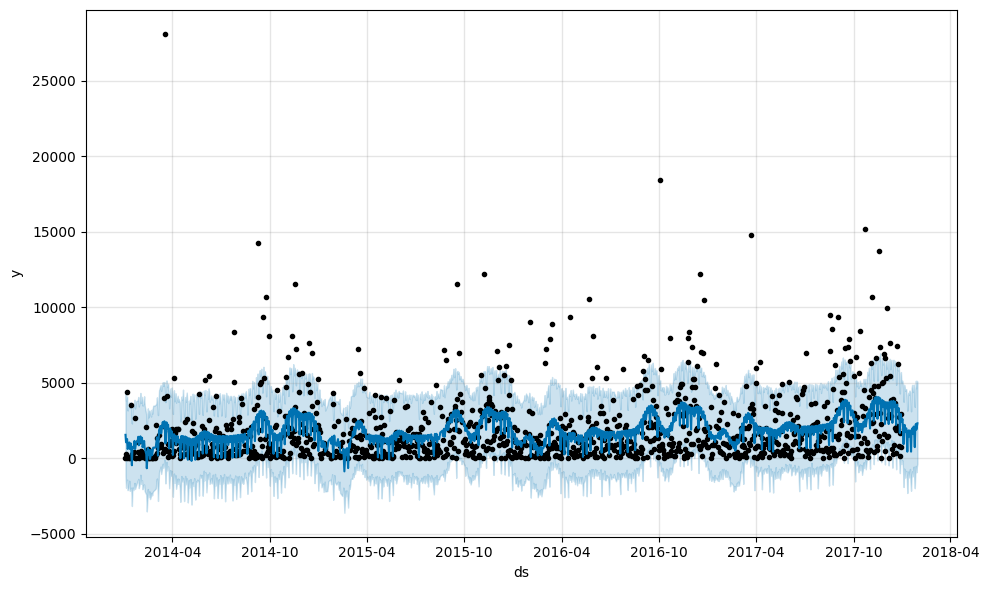

In [71]:
fig = model.plot(forecast)

## Forecast Components

This visualization shows how trend and seasonality contribute to the forecast.

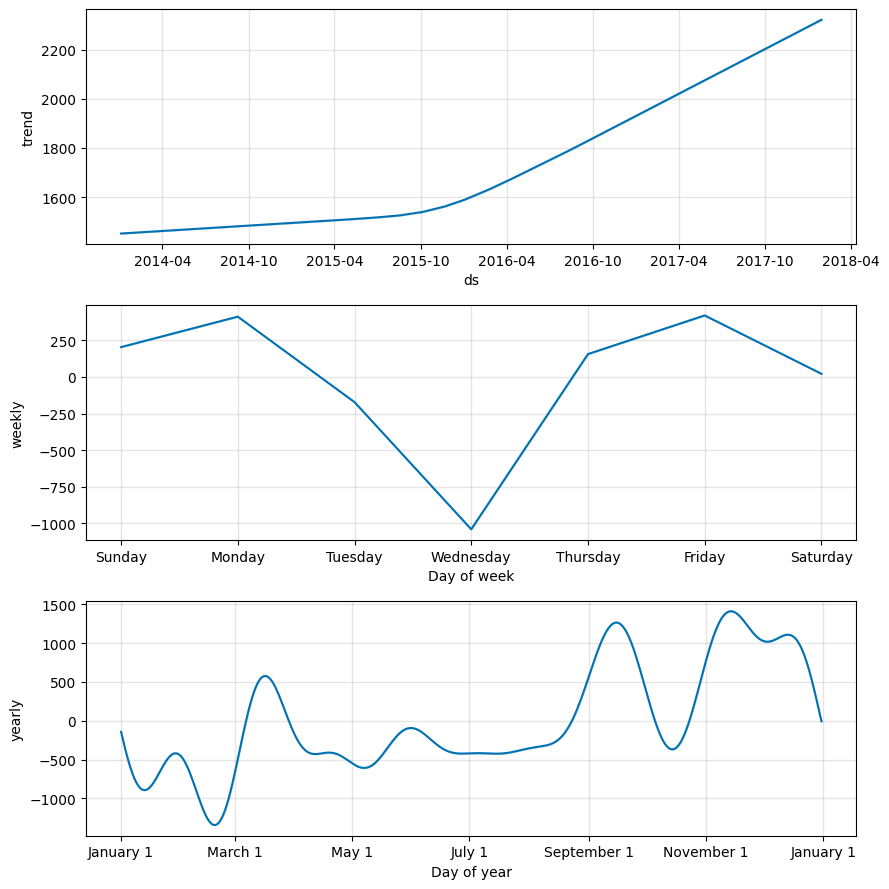

In [72]:
fig2 = model.plot_components(forecast)

## Model Comparison: Linear Regression vs Random Forest vs Prophet

In this project, three different models were used to forecast sales: Linear Regression, Random Forest, and Prophet. Each model represents a different approach to prediction.

Linear Regression is a simple baseline model that assumes a straight-line relationship between features and sales. It is easy to understand and fast to train, but it struggled to capture complex patterns in the data, especially sudden spikes and fluctuations.

Random Forest, a Machine Learning model, improved upon this by capturing non-linear relationships between features such as discount, category, and quantity. It was better at following variations in sales, but still depends heavily on feature engineering and does not naturally understand time-based patterns.

Prophet, a time-series forecasting model, focuses on trends and seasonality over time. It provided smoother and more interpretable predictions, clearly showing long-term growth and weekly or yearly patterns. However, it may not react quickly to sudden spikes like Random Forest.

Overall, Linear Regression serves as a baseline, Random Forest improves predictive power for complex relationships, and Prophet provides strong insights for time-based forecasting.

In real-world business scenarios, combining these approaches can lead to better decision-making by balancing accuracy and interpretability.

## Prophet Model Insights

The Prophet model reveals important patterns in the sales data.

There is a clear upward trend, indicating business growth over time.

Weekly patterns show that sales vary significantly by day of the week, with some days performing better than others.

Yearly seasonality suggests that certain periods of the year experience higher sales, likely due to demand cycles or promotions.

However, the wide uncertainty range indicates that sales can fluctuate significantly, making exact predictions challenging.

## Conclusion

In this project, we successfully built and compared multiple models for sales forecasting using historical business data.

We started with Linear Regression as a simple baseline model, which provided a basic understanding of the relationship between features and sales but struggled with complex patterns.

We then applied Random Forest, which improved prediction performance by capturing non-linear relationships and variations in the data. However, it required feature engineering and did not inherently understand time-based patterns.

Finally, we used Prophet, a time-series forecasting model, which effectively captured overall trends and seasonality. It provided smoother and more interpretable forecasts, making it highly useful for long-term business planning.

Each model has its strengths:
- Linear Regression: simplicity and interpretability
- Random Forest: handling complex relationships
- Prophet: understanding trends and seasonality

From a business perspective, combining these approaches can provide both accurate predictions and meaningful insights.

This project demonstrates how data-driven forecasting can support better decision-making in areas such as inventory management, staffing, and financial planning.

## Limitations and Future Improvements

While this project provides useful insights into sales forecasting, there are some limitations to consider.

The models were trained on historical data with limited features, and some important business factors such as promotions, holidays, and external market conditions were not included. These factors can significantly influence sales patterns.

Additionally, the Random Forest model depends heavily on feature engineering, while the Prophet model focuses more on overall trends and may not capture sudden spikes accurately.

For future improvements, the model could be enhanced by:
- Including more relevant business features such as promotions or customer behavior
- Using advanced time-series techniques or hybrid models
- Performing hyperparameter tuning for better performance
- Evaluating models using cross-validation for more robust results

Improving these areas can lead to more accurate and reliable forecasting, making the system more valuable for real-world business applications.